
# Skip-Gram Word Embeddings (Notebook Version)

A notebook translation of `train_embeddings.py`: reads a text corpus,
tokenizes it, builds a vocabulary, and trains word embeddings with a
Skip-Gram model + negative sampling \u2014 a minimal, dependency-light
re-implementation of word2vec using only NumPy.

Two changes from the original command-line script, both purely to fit the
notebook format:

- **No `argparse`.** The `--corpus`, `--out`, `--track-words`, etc. flags
  are now plain variables in the *Configuration* cell below \u2014 edit them
  directly instead of passing command-line arguments.
- **Self-contained.** The original script's `GENERATE_MOVIE` step imports
  a companion file, `plot_embedding_evolution.py`. That module's code is
  included directly in this notebook (clearly marked below) so the whole
  pipeline runs standalone, with no second file required.

Everything else \u2014 every function, every hyperparameter, the training
loop itself \u2014 is unchanged from the original script.


In [21]:

import argparse
import re
import numpy as np
from collections import Counter


In [22]:

# --------------------------------------------------------------------------
# HYPERPARAMETERS (edit these to tune training)
# --------------------------------------------------------------------------
EMBEDDING_DIM = 100
WINDOW_SIZE = 4
MIN_COUNT = 5
NEGATIVE_SAMPLES = 5
EPOCHS = 5
LEARNING_RATE = 0.025
BATCH_SEED = 42
LOWERCASE = True
TRACK_TOP_N = 15
SNAPSHOT_EVERY = 500
GENERATE_MOVIE = True
# --------------------------------------------------------------------------
#   EMBEDDING_DIM     : int   - Dimensionality of each word vector.
#   WINDOW_SIZE       : int   - Max distance between target and context word.
#   MIN_COUNT         : int   - Ignore words with total frequency below this.
#   NEGATIVE_SAMPLES  : int   - Number of negative samples drawn per positive pair.
#   EPOCHS            : int   - Number of full passes over the training pairs.
#   LEARNING_RATE     : float - Step size for gradient updates (SGD).
#   BATCH_SEED        : int   - RNG seed, for reproducible shuffling/sampling.
#   LOWERCASE         : bool  - Whether to lowercase text before tokenizing.
#   TRACK_TOP_N       : int   - Number of most-frequent words to track for the
#                                embedding-evolution movie.
#   SNAPSHOT_EVERY    : int   - Record a snapshot of the tracked words' vectors
#                                every this-many training pairs processed.
#   GENERATE_MOVIE    : bool  - If True, render the PNG movie frames after training.


## Core functions (unchanged from `train_embeddings.py`)

In [23]:

def read_corpus(path: str) -> str:
    """Load raw text from a UTF-8 file."""
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def tokenize(text: str) -> list[str]:
    """Split text into word tokens, stripping punctuation.
    Includes Danish letters (\u00e6, \u00f8, \u00e5) alongside the basic Latin alphabet."""
    if LOWERCASE:
        text = text.lower()
    # Keep alphanumeric sequences (including simple contractions like "don't")
    return re.findall(r"[a-z\u00e6\u00f8\u00e5" + "0-9']+", text)


def build_vocab(tokens: list[str]):
    """Build word<->index maps, dropping rare words (< MIN_COUNT)."""
    counts = Counter(tokens)
    vocab = [w for w, c in counts.items() if c >= MIN_COUNT]
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    freqs = np.array([counts[w] for w in vocab], dtype=np.float64)
    return word2idx, idx2word, freqs


def make_training_pairs(tokens: list[str], word2idx: dict) -> list[tuple[int, int]]:
    """Generate (target, context) index pairs within WINDOW_SIZE."""
    ids = [word2idx[t] for t in tokens if t in word2idx]
    pairs = []
    for pos, target in enumerate(ids):
        start = max(0, pos - WINDOW_SIZE)
        end = min(len(ids), pos + WINDOW_SIZE + 1)
        for ctx_pos in range(start, end):
            if ctx_pos != pos:
                pairs.append((target, ids[ctx_pos]))
    return pairs


def negative_sampling_table(freqs: np.ndarray, table_size: int = 1_000_000) -> np.ndarray:
    """Build a sampling table biased toward frequent words (unigram^0.75)."""
    weights = freqs ** 0.75
    weights /= weights.sum()
    counts = np.round(weights * table_size).astype(int)
    table = np.repeat(np.arange(len(freqs)), counts)
    return table


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))


In [24]:
def train_skipgram(
    pairs,
    vocab_size,
    neg_table,
    rng,
    tracked_ids=None
):
    """
    Train Skip-Gram embeddings with negative sampling.
    Maintains two matrices: 'in' vectors (target/word) and 'out' vectors
    (context), following the standard word2vec formulation.

    If `tracked_ids` is given, a snapshot of those rows of W_in is recorded
    every SNAPSHOT_EVERY processed pairs, giving a time series of how those
    words move through embedding space over the course of training (used
    to render the evolution "movie" below).
    """
    W_in = (rng.random((vocab_size, EMBEDDING_DIM)) - 0.5) / EMBEDDING_DIM
    W_out = np.zeros((vocab_size, EMBEDDING_DIM))

    snapshot_steps = []
    snapshots = []
    step = 0

    def maybe_snapshot():
        if tracked_ids is not None and step % SNAPSHOT_EVERY == 0:
            snapshot_steps.append(step)
            snapshots.append(W_in[tracked_ids].copy())

    maybe_snapshot()  # capture the random initial positions (step 0)

    for epoch in range(EPOCHS):
        rng.shuffle(pairs)
        total_loss = 0.0
        for target, context in pairs:
            v_in = W_in[target]

            # Positive sample: target should predict context word.
            pos_score = sigmoid(np.dot(v_in, W_out[context]))
            grad_pos = (pos_score - 1.0) * LEARNING_RATE
            in_grad = grad_pos * W_out[context]
            W_out[context] -= grad_pos * v_in
            total_loss += -np.log(pos_score + 1e-10)

            # Negative samples: target should NOT predict random words.
            neg_ids = neg_table[rng.integers(0, len(neg_table), NEGATIVE_SAMPLES)]
            for neg in neg_ids:
                neg_score = sigmoid(np.dot(v_in, W_out[neg]))
                grad_neg = neg_score * LEARNING_RATE
                in_grad += grad_neg * W_out[neg]
                W_out[neg] -= grad_neg * v_in
                total_loss += -np.log(1.0 - neg_score + 1e-10)

            W_in[target] -= in_grad

            step += 1
            maybe_snapshot()

        print(f"Epoch {epoch + 1}/{EPOCHS} - avg loss: {total_loss / len(pairs):.4f}")

    history = None
    if tracked_ids is not None:
        history = {
            "steps": np.array(snapshot_steps),
            "embeddings": np.stack(snapshots),  # (n_snapshots, n_tracked, dim)
        }

    return W_in, history



## Movie-rendering functions (from `plot_embedding_evolution.py`, inlined)

The original script calls out to a companion file for the PCA-projection
and frame-rendering logic behind `GENERATE_MOVIE`. That file's contents are
reproduced here unchanged, just moved into this notebook so nothing external
is required.


In [25]:

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the '3d' projection)

# ---------------------------- Hyperparameters ---------------------------- #
PCA_MODE = "detrend"       # "pooled" | "final" | "detrend"
PLOT_DIMS = 3              # 2 or 3
TRAIL_LENGTH = 8
FIGSIZE = (7, 7)
DPI = 120
POINT_COLOR = "#1f77b4"
PADDING_FRAC = 0.15
ROTATE_VIEW = True
ROTATION_DEG_PER_FRAME = 0.6
ELEV = 20.0
# --------------------------------------------------------------------------- #
#   PCA_MODE: how the PCA basis is chosen.
#     "pooled"  - fit on all snapshots x all tracked words pooled together.
#                 Simple, but a big shared drift (all words moving away from
#                 their random init together) can dominate the leading
#                 component(s), squeezing word-to-word differences out.
#     "final"   - fit only on the LAST snapshot, then reuse that basis for
#                 every frame, so axes best separate the words' end states.
#     "detrend" - subtract each snapshot's own across-word mean before
#                 fitting AND plotting, removing the shared drift so only
#                 word-to-word differences remain.
#   PLOT_DIMS: 2 or 3 -- a flat scatter, or a rotating 3D scatter.


def _fit_svd_components(X: np.ndarray, n_components: int):
    """Center X and return (mean, top-n_components right-singular vectors)."""
    mean = X.mean(axis=0)
    centered = X - mean
    _, _, Vt = np.linalg.svd(centered, full_matrices=False)
    return mean, Vt[:n_components]


def compute_projection(embeddings: np.ndarray, mode: str, n_components: int) -> np.ndarray:
    """
    Compute a fixed, shared PCA projection of the (n_snapshots, n_words, dim)
    embedding history down to n_components dimensions, according to `mode`.
    Returns an array of shape (n_snapshots, n_words, n_components).
    """
    n_snapshots, n_words, dim = embeddings.shape

    if mode == "pooled":
        pooled = embeddings.reshape(-1, dim)
        mean, components = _fit_svd_components(pooled, n_components)
        projected = (embeddings - mean) @ components.T

    elif mode == "final":
        mean, components = _fit_svd_components(embeddings[-1], n_components)
        projected = (embeddings - mean) @ components.T

    elif mode == "detrend":
        frame_means = embeddings.mean(axis=1, keepdims=True)  # (n_snapshots, 1, dim)
        detrended = embeddings - frame_means
        mean, components = _fit_svd_components(detrended.reshape(-1, dim), n_components)
        projected = (detrended - mean) @ components.T

    else:
        raise ValueError(f"Unknown PCA_MODE: {mode!r} (expected 'pooled', 'final', or 'detrend')")

    return projected  # (n_snapshots, n_words, n_components)


def _axis_limits(coords: np.ndarray):
    """Fixed (min, max) per axis across the whole trajectory, with padding."""
    lo = coords.reshape(-1, coords.shape[-1]).min(axis=0)
    hi = coords.reshape(-1, coords.shape[-1]).max(axis=0)
    pad = (hi - lo) * PADDING_FRAC
    pad[pad == 0] = 1.0
    return list(zip(lo - pad, hi + pad))


def render_frames(history_path: str, frames_dir: str, pca_mode: str = PCA_MODE,
                   plot_dims: int = PLOT_DIMS):
    """
    Load a training history (.npz) and write one PNG per snapshot to
    `frames_dir`, showing each tracked word's position (and a short fading
    trail of its recent past positions) in a shared, fixed PCA projection.
    """
    import os
    os.makedirs(frames_dir, exist_ok=True)
    data = np.load(history_path, allow_pickle=True)
    steps = data["steps"]                 # (n_snapshots,)
    embeddings = data["embeddings"]       # (n_snapshots, n_words, dim)
    words = data["words"]                 # (n_words,)

    n_snapshots, n_words, dim = embeddings.shape
    print(f"Loaded {n_snapshots} snapshots for {n_words} tracked words (dim={dim}).")
    print(f"PCA mode: '{pca_mode}', plotting in {plot_dims}D.")

    projected_all = compute_projection(embeddings, pca_mode, plot_dims)
    limits = _axis_limits(projected_all)  # [(xmin,xmax), (ymin,ymax), (zmin,zmax)?]

    for frame_idx in range(n_snapshots):
        fig = plt.figure(figsize=FIGSIZE)
        ax = fig.add_subplot(111, projection="3d" if plot_dims == 3 else None)
        ax.set_xlim(*limits[0])
        ax.set_ylim(*limits[1])
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        if plot_dims == 3:
            ax.set_zlim(*limits[2])
            ax.set_zlabel("PC 3")
            if ROTATE_VIEW:
                ax.view_init(elev=ELEV, azim=frame_idx * ROTATION_DEG_PER_FRAME)
        ax.set_title(f"Embedding relaxation \u2014 step {steps[frame_idx]} ({pca_mode})")

        # Draw a fading trail of each word's recent past positions.
        trail_start = max(0, frame_idx - TRAIL_LENGTH)
        for w in range(n_words):
            trail = projected_all[trail_start:frame_idx + 1, w]
            for t in range(len(trail) - 1):
                alpha = (t + 1) / len(trail) * 0.5  # older = more transparent
                seg = trail[t:t + 2]
                if plot_dims == 3:
                    ax.plot(seg[:, 0], seg[:, 1], seg[:, 2],
                            color=POINT_COLOR, alpha=alpha, linewidth=1.5)
                else:
                    ax.plot(seg[:, 0], seg[:, 1],
                            color=POINT_COLOR, alpha=alpha, linewidth=1.5)

        # Current position + label for each word.
        current = projected_all[frame_idx]
        if plot_dims == 3:
            ax.scatter(current[:, 0], current[:, 1], current[:, 2],
                       color=POINT_COLOR, s=40, depthshade=True)
            for w in range(n_words):
                ax.text(current[w, 0], current[w, 1], current[w, 2],
                        str(words[w]), fontsize=8)
        else:
            ax.scatter(current[:, 0], current[:, 1], color=POINT_COLOR, s=40, zorder=3)
            for w in range(n_words):
                ax.annotate(str(words[w]), (current[w, 0], current[w, 1]),
                            fontsize=9, xytext=(4, 4), textcoords="offset points")

        fig.tight_layout()
        frame_path = os.path.join(frames_dir, f"frame_{frame_idx:04d}.png")
        fig.savefig(frame_path, dpi=DPI)
        plt.close(fig)

    print(f"Wrote {n_snapshots} frames to '{frames_dir}/'.")



## Configuration

This replaces the original script's `argparse` flags. Edit these directly
instead of passing command-line arguments.

If `CORPUS_PATH` doesn't exist, a small demo corpus is written there
automatically so the notebook runs out of the box \u2014 point it at your own
text file to use real data.


In [26]:

CORPUS_PATH = "corpus.txt"          # --corpus
OUT_PREFIX = "embeddings"           # --out
FRAMES_DIR = "frames"               # --frames-dir
TRACK_WORDS = None                  # --track-words   e.g. ["fox", "dog", "hjerte"]; None = auto (TRACK_TOP_N)
PCA_MODE_OVERRIDE = None            # --pca-mode      "pooled" | "final" | "detrend" | None (use PCA_MODE above)
DIMS_OVERRIDE = None                # --dims          2 | 3 | None (use PLOT_DIMS above)
MIN_COUNT_OVERRIDE = None           # --min-count     int | None (use MIN_COUNT above)
EPOCHS_OVERRIDE = None              # --epochs        int | None (use EPOCHS above)
SNAPSHOT_EVERY_OVERRIDE = None      # --snapshot-every int | None (use SNAPSHOT_EVERY above)

import os
if not os.path.exists(CORPUS_PATH):
    demo_text = (
        "The quick brown fox jumps over the lazy dog. Natural Language Processing with "
        "Python is incredibly powerful. Word2Vec maps text tokens into dense numerical "
        "vector spaces. S\u00e5 tag mit hjerte i dine h\u00e6nder, og grib det forsigtigt og "
        "uden rung, det ved, at solen og m\u00e5nen br\u00e6nder, og at det er lille og det er "
        "ung. Det r\u00f8de hjerte \u2013 nu er det dit. Nu er det stille \u2013 nu er det dit. Og det "
        "kan glemme og glemme tit, men glemmer aldrig, at det er dit. Nu kan det knuses "
        "\u2013 men kun af dig. Det ved, at vejen er lang og smal. Men det vil ikke g\u00e5 uden "
        "dig,og det vil d\u00f8 i din stumme sal."
    )
    with open(CORPUS_PATH, "w", encoding="utf-8") as f:
        f.write(demo_text)
    # This demo corpus is tiny, so relax MIN_COUNT/EPOCHS/SNAPSHOT_EVERY accordingly.
    MIN_COUNT_OVERRIDE = 1
    EPOCHS_OVERRIDE = 200
    SNAPSHOT_EVERY_OVERRIDE = 750
    print(f"No corpus found at {CORPUS_PATH!r} \u2014 wrote a small demo corpus there instead.")


## Run the pipeline (equivalent to `main()` in the original script)

In [27]:

# Allow overrides, exactly like the script's CLI flags did.
if MIN_COUNT_OVERRIDE is not None:
    MIN_COUNT = MIN_COUNT_OVERRIDE
if EPOCHS_OVERRIDE is not None:
    EPOCHS = EPOCHS_OVERRIDE
if SNAPSHOT_EVERY_OVERRIDE is not None:
    SNAPSHOT_EVERY = SNAPSHOT_EVERY_OVERRIDE

rng = np.random.default_rng(BATCH_SEED)

# 1. Read and tokenize
text = read_corpus(CORPUS_PATH)
tokens = tokenize(text)
print(f"Read {len(tokens)} tokens from corpus.")

# 2. Build vocabulary
word2idx, idx2word, freqs = build_vocab(tokens)
print(f"Vocabulary size (min_count={MIN_COUNT}): {len(word2idx)}")

# 3. Build training pairs and negative sampling table
pairs = make_training_pairs(tokens, word2idx)
print(f"Generated {len(pairs)} (target, context) training pairs.")
neg_table = negative_sampling_table(freqs)

# 3b. Choose which words to track for the embedding-evolution movie.
if TRACK_WORDS:
    tracked_words = [w for w in TRACK_WORDS if w in word2idx]
else:
    tracked_words = [w for w, _ in
                      Counter({w: freqs[i] for w, i in word2idx.items()})
                      .most_common(TRACK_TOP_N)]
tracked_ids = np.array([word2idx[w] for w in tracked_words])
print(f"Tracking {len(tracked_words)} words for the evolution movie: {tracked_words}")

# 4. Train embeddings (recording periodic snapshots of the tracked words)
embeddings, history = train_skipgram(pairs, len(word2idx), neg_table, rng, tracked_ids)


Read 116 tokens from corpus.
Vocabulary size (min_count=5): 3
Generated 220 (target, context) training pairs.
Tracking 3 words for the evolution movie: ['det', 'og', 'er']
Epoch 1/5 - avg loss: 4.1209
Epoch 2/5 - avg loss: 3.0381
Epoch 3/5 - avg loss: 2.7159
Epoch 4/5 - avg loss: 2.7096
Epoch 5/5 - avg loss: 2.7163


In [28]:

# 5. Save results
np.save(f"{OUT_PREFIX}.npy", embeddings)
with open(f"{OUT_PREFIX}.vocab.txt", "w", encoding="utf-8") as f:
    for i in range(len(idx2word)):
        f.write(idx2word[i] + "\n")
history_path = f"{OUT_PREFIX}.history.npz"
np.savez(history_path, steps=history["steps"], embeddings=history["embeddings"],
          words=np.array(tracked_words))
print(f"Saved embeddings to {OUT_PREFIX}.npy and vocabulary to {OUT_PREFIX}.vocab.txt")
print(f"Saved embedding-evolution history to {history_path}")


Saved embeddings to embeddings.npy and vocabulary to embeddings.vocab.txt
Saved embedding-evolution history to embeddings.history.npz


In [29]:

# 6. Optionally render the PNG movie frames right away.
if GENERATE_MOVIE:
    pca_mode = PCA_MODE_OVERRIDE or PCA_MODE
    plot_dims = DIMS_OVERRIDE or PLOT_DIMS
    render_frames(history_path, FRAMES_DIR, pca_mode, plot_dims)


Loaded 3 snapshots for 3 tracked words (dim=100).
PCA mode: 'detrend', plotting in 3D.
Wrote 3 frames to 'frames/'.



## Bonus: preview a frame, and export the movie as MP4

Not part of the original script, but a natural next step now that we're in
a notebook \u2014 inline previewing and an MP4 export using `ffmpeg`.


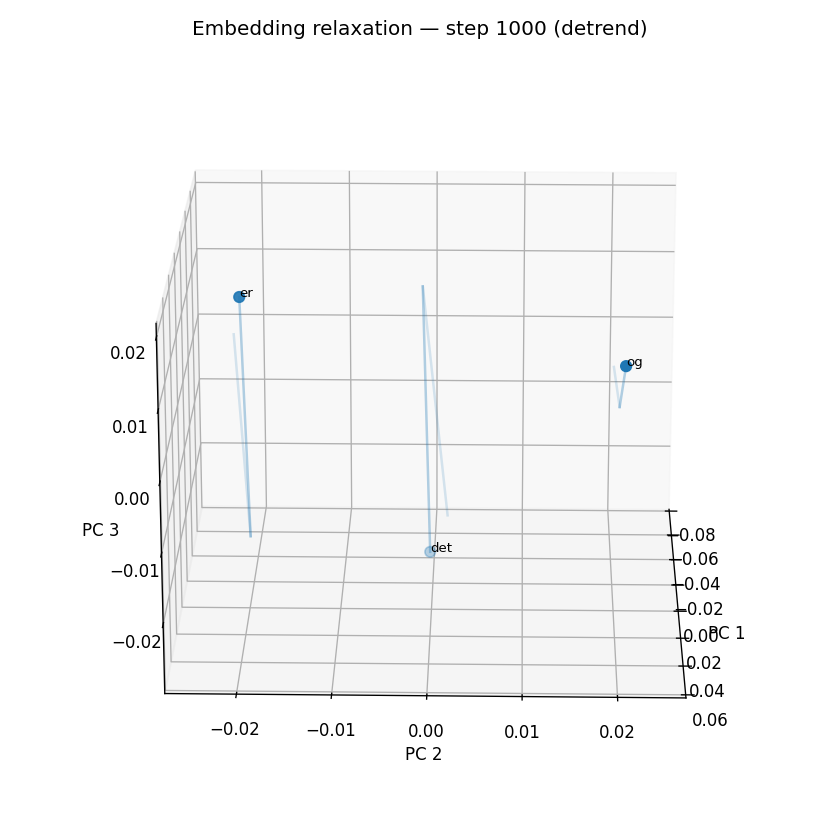

In [30]:

from IPython.display import Image, display

if GENERATE_MOVIE:
    last_frame = sorted(os.listdir(FRAMES_DIR))[-1]
    display(Image(filename=os.path.join(FRAMES_DIR, last_frame)))


In [31]:

import subprocess

OUTPUT_MP4 = f"{OUT_PREFIX}_relaxation.mp4"
FRAMERATE = 15

if GENERATE_MOVIE:
    cmd = [
        "ffmpeg", "-y", "-framerate", str(FRAMERATE),
        "-i", os.path.join(FRAMES_DIR, "frame_%04d.png"),
        "-pix_fmt", "yuv420p",
        "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
        OUTPUT_MP4,
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr[-2000:])
        raise RuntimeError("ffmpeg failed \u2014 is it installed and on PATH?")
    print(f"Saved {OUTPUT_MP4}")


FileNotFoundError: [Errno 2] No such file or directory: 'ffmpeg'

In [ ]:

from IPython.display import Video

if GENERATE_MOVIE:
    display(Video(OUTPUT_MP4, embed=True, width=700))
